#🔎**Problema: Optimización del Cronograma de una Vivienda**

###📖**Contexto:**
* Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.

###🧠**El Desafío:**
* La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

###📝**Consigna:**
* Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

##🛠️**Pasos para la Resolución (Hoja de Ruta)**

* 1️⃣**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

* 2️⃣**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

* 3️⃣**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

* 4️⃣**Importante:** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

---

* 🎯Como queremos minimizar el tiempo, el fitness podría ser:

$$Fitness = \frac{1}{DíasTotales}$$

---

* 5️⃣**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

* 6️⃣**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

* 7️⃣**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

---

💡**Razonamiento:**
* *Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [9]:
# Instalación de las librerías necesarias.
!pip install pygad deap matplotlib numpy

In [7]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Datos del problema.
# Diccionario de tareas: {ID: (Duración, Operarios)}.
TASAS_OBRA = {
  0: (5, 4),  # Cimientos
  1: (7, 6),  # Muros
  2: (4, 5),  # Techo
  3: (6, 3),  # Instalaciones
  4: (5, 4),  # Revoque
  5: (4, 3),  # Pisos
  6: (3, 2),  # Pintura
  7: (2, 3),  # Aberturas
  8: (4, 2),  # Electricidad
  9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

In [11]:
# Definición de la función de aptitud.
def fitness_func(ga_instance, solution, solution_idx):

  # Se redondea los genes a enteros.
  dias_inicio = np.round(solution).astype(int)

  dia_final_obra = 0
  castigo = 0

  # Diccionario para anotar cuántos operarios están trabajando cada día.
  operarios_por_dia = {}

  # Cálculo de tiempo y asignación.
  for tarea_id in range(NUM_TAREAS):
    dia_inicio_tarea = dias_inicio[tarea_id]
    duracion, operarios_necesarios = TASAS_OBRA[tarea_id]

    # Se calcula cuándo termina esta tarea específica.
    dia_fin_tarea = dia_inicio_tarea + duracion

    # El tiempo total de la obra será el dia de fin más lejano.
    if dia_fin_tarea > dia_final_obra:
      dia_final_obra = dia_fin_tarea

    # Se anota los operarios usados en el calendario.
    # Si la tarea dura 5 días, se suma operarioos a esos 5 días.
    for dia in range(dia_inicio_tarea, dia_fin_tarea):

      if dia not in operarios_por_dia:
        operarios_por_dia[dia] = 0

      operarios_por_dia[dia] += operarios_necesarios

  # Restricción A: el algoritmo no puede inventar días negativos para empezar antes.
  for dia_inicio_tarea in dias_inicio:

    if dia_inicio_tarea < 0:
      castigo += 500 # Castigo fuerte por romper leyes de tiempo.

  # Restricción B: no se puede exceder los 10 operarios por día.
  for dia, total_operarios in operarios_por_dia.items():

    if total_operarios > MAX_OPERARIOS:

      # Se multiplica el exceso por 100.
      exceso = total_operarios - MAX_OPERARIOS
      castigo += (exceso * 100)

  # Se suma el timepo real que tardó + los castigos por romper reglas.
  error_total = dia_final_obra + castigo

  # Se transforma a fracción para que PyGAD busque el número más alto.
  aptitud_final = 1.0 / (error_total + 1.0)

  return aptitud_final

In [12]:
# Configuración del algoritmo genético.
ga_instance = pygad.GA(

  num_generations=100, # 100 ciclos evolutivos para buscar el mejor cronograma.
  sol_per_pop=50, # 50 cronogramas distintos compitiendo a la vez.
  fitness_func=fitness_func, # se referencia a la función de aptitud.

  num_genes=NUM_TAREAS, # 10 tareas = 10 genes.
  gene_type=int, # los días de inicio son números enteros.
  init_range_low=0, # empiezan del día 0 en adelante.
  init_range_high=30, # límite superior inicial arbitrario (mes 1).

  num_parents_mating=10, # los mejores 10 pasan sus genes.
  parent_selection_type="tournament",
  K_tournament=3,
  crossover_type="single_point",
  mutation_type="random",
  mutation_percent_genes=20 # Mutación al 20% para explorar más combinaciones de días.
)

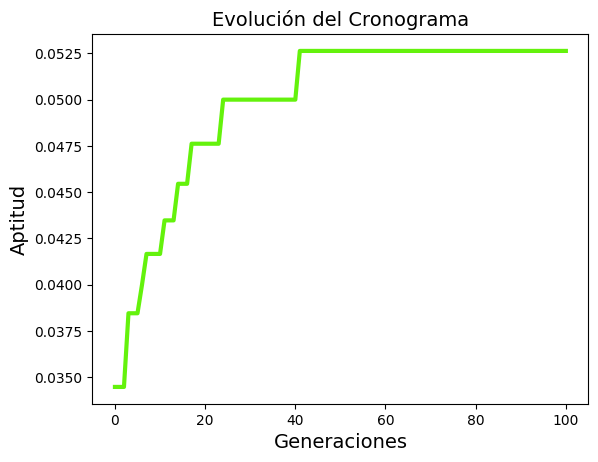

          CRONOGRAMA ÓPTIMO              
Orden de días de inicio por tarea: [11  4  0  5  0 14 11 15 11 11]
Tiempo total de la obra (Makespan): 18 días


In [13]:
# Ejecución final y resultado.
ga_instance.run()

ga_instance.plot_fitness(title="Evolución del Cronograma",
                         xlabel="Generaciones",
                         ylabel="Aptitud")
plt.show()

# Se extrae la mejor combinación histórica.
mejor_solucion, mejor_aptitud, indice = ga_instance.best_solution()

# Se revierte la fórmula matemática para obtener día reales.
tiempo_real_obra = int((1.0 / mejor_aptitud) - 1.0)

print("=========================================")
print("          CRONOGRAMA ÓPTIMO              ")
print("=========================================")
print(f"Orden de días de inicio por tarea: {mejor_solucion}")
print(f"Tiempo total de la obra (Makespan): {tiempo_real_obra} días")